**Author:** Tianqi Shen & GPT-4o

**Date:** 28 May 2026

# Empirical Evidence for Muon as an Early Exploration Optimizer
## Mixed-spiked Matrix Sensing Case ($\Sigma$ is PSD matrix)

To examine when Muon performs well, we consider the mixed-spiked matrix sensing (MS) problem proposed in our paper. 

Recall that we define three projection matrices: $P_\star\in\mathbb{R}^{n\times r}$ (signal), $P_\diamond\in\mathbb{R}^{n\times r}$ (spike), and $P_\circ\in\mathbb{R}^{n\times r}$ (bulk). Let
$$
    P_\star P_\star^\top := U \in \mathbb{R}^{n\times n},
    \qquad
    P_\diamond P_\diamond^\top := V \in \mathbb{R}^{n\times n},
    \qquad
    P_\circ P_\circ^\top := W \in \mathbb{R}^{n\times n},
$$
and assume orthonormal columns, i.e., $P_\star^\top P_\star = P_\diamond^\top P_\diamond = P_\circ^\top P_\circ = I_r$.
We consider the objective
$$
    \mathcal{L}(X) := \mathcal{F}(XX^\top) :=
    \min_{X\in\mathbb{R}^{n\times r}}
    \frac{1}{2} \mathbb{E}
    \left[
        \left\langle
            A,
            XX^\top - P_\star
        \right\rangle^2
    \right],
    \\
    \Leftrightarrow
    \mathcal{F}(M) = \frac{1}{n} \|M-P_\star\|_F^2 + \frac12
    \begin{bmatrix}
        \langle P_\star, M-P_\star \rangle \\
        \langle P_\diamond, M \rangle \\
        \langle P_\circ, M \rangle 
    \end{bmatrix}^\top
    \Sigma
    \begin{bmatrix}
        \langle P_\star, M-P_\star \rangle \\
        \langle P_\diamond, M \rangle \\
        \langle P_\circ, M \rangle 
    \end{bmatrix},
$$
with square matrix variable $M:=XX^\top\in \mathbb{R}^{n\times n}$.
The sensing matrix $A$ is sampled as
$$
    A = G + \pi_\star P_\star + \pi_\diamond P_\diamond + \pi_\circ P_\circ,
$$
where $G\sim \mathrm{GOE}(n)$ is an isotropic Gaussian noise component, and $\pi:=[\pi_\star,\pi_\diamond,\pi_\circ]^\top\sim\mathcal{N}(0,\Sigma)$
with $\Sigma\succeq 0$ (here, PSD) a covariance matrix.
We also define the following matrix (here, PSD)
$$
    \hat{K} := \frac{2r}{n} I_3 + r^2 \Sigma 
    :=
    \begin{bmatrix}
        \hat{K}_{11} & \hat{K}_{12} & \hat{K}_{13} \\
        \hat{K}_{21} & \hat{K}_{22} & \hat{K}_{23} \\
        \hat{K}_{31} & \hat{K}_{32} & \hat{K}_{33}
    \end{bmatrix}.
$$

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import argparse
import numpy as np
from typing import List, Tuple
from itertools import chain
from tqdm import tqdm
from dataclasses import dataclass
Array = np.ndarray

### Load hyper-parameters

In [2]:
L = np.array([[0.1, 0.5, 0.8]], dtype=float)
print("Sigma:\n", L.T @ L)  # Sigma = L.T @ L is a PSD matrix

# Load hyper-parameters
class Args:
    Sigma = L.T @ L
    K = None
    n = 48
    r = 16  # r+r+r=n
    a0 = 0.1
    b0 = 0.6
    c0 = 0.3
    steps = 4000
    eta0 = 0.02  # step-size of simplified Muon
    eta1 = 0.02  # step-size of vanilla GD
    switch_step = 100  # switch step must satisfy 0 < switch_step < steps
    project_gd = True
    sign_deadzone = 0.0
    eps = 1e-14
args = Args()

def validate_psd_matrix(M: Array, tol: float = 1e-10) -> Array:
    """Return a symmetrized 3x3 PSD matrix, raising if the matrix is invalid."""
    M = np.asarray(M, dtype=float)
    if M.shape != (3, 3):
        raise ValueError(f"Input must be a 3x3 matrix.")
    M = 0.5 * (M + M.T)
    min_eig = float(np.linalg.eigvalsh(M).min())
    if min_eig < -tol:
        raise ValueError(f"Input must be positive semidefinite; min eigenvalue = {min_eig:.3e}.")
    return M

args.Sigma = validate_psd_matrix(args.Sigma)

def Sigma2K(Sigma, n: int, r: int):
    """Given K = (2r/n) * I_3 + r^2 * Sigma, return K."""
    Sigma = np.asarray(Sigma, dtype=float)
    I3 = np.eye(3, dtype=float)
    K = (2 * r / n) * I3 + (r ** 2) * Sigma
    return K

args.K = validate_psd_matrix(Sigma2K(args.Sigma, args.n, args.r))

Sigma:
 [[0.01 0.05 0.08]
 [0.05 0.25 0.4 ]
 [0.08 0.4  0.64]]


### Functional helpers for reduced gradient, loss and distance
The Frobenius gradient of $\mathcal{F}$ with respect to $M$ is
$$
    G(M) := \nabla_M \mathcal{F}(M) = 
    \frac{2}{n} (M-P_\star) + g_\star P_\star + g_\diamond P_\diamond + g_\circ P_\circ,
$$
where
$$
    \begin{bmatrix} g_\star \\ g_\diamond \\ g_\circ \end{bmatrix} = \Sigma 
    \begin{bmatrix}
        \langle P_\star, M-P_\star \rangle \\
        \langle P_\diamond, M \rangle \\
        \langle P_\circ, M \rangle 
    \end{bmatrix} \in \mathbb{R}^3.
$$
On the invariant manifold $\mathcal{M}$:
$$
    \mathcal{M} :=
    \left\{
        M = \alpha P_\star + \beta P_\diamond + \gamma P_\circ
        :\; \alpha,\beta,\gamma \in \mathbb{R}
    \right\},
$$
the Frobenius gradient $G(M)$ reduces to $G(M) := u P_\star + v P_\diamond + w P_\circ$, where
$$
    \begin{bmatrix} u \\ v \\ w \end{bmatrix} = \frac{2}{n}
    \begin{bmatrix} \alpha-1 \\ \beta \\ \gamma \end{bmatrix} + 
    \Sigma \begin{bmatrix} r(\alpha-1) \\ r\beta \\ r\gamma \end{bmatrix}.
$$
The reduced loss $f(\alpha,\beta,\gamma)$ is thus
$$
    f(\alpha,\beta,\gamma) 
    = \frac{r}{n} [(\alpha-1)^2 + \beta^2 + \gamma^2] + \frac12
    \begin{bmatrix} r(\alpha-1) \\ r\beta \\ r\gamma \end{bmatrix}^\top
    \Sigma \begin{bmatrix} r(\alpha-1) \\ r\beta \\ r\gamma \end{bmatrix}
    = \frac12
    \begin{bmatrix} \alpha-1 \\ \beta \\ \gamma \end{bmatrix}^\top
    \hat{K}
    \begin{bmatrix} \alpha-1 \\ \beta \\ \gamma \end{bmatrix}.
$$
The squared distance to the ground truth $P_\star$ reduces to
$$
    \|(\alpha-1) P_\star + \beta P_\diamond + \gamma P_\circ\|_F^2 = 
    \operatorname{Tr}\left\{
    \left[(\alpha-1) P_\star + \beta P_\diamond + \gamma P_\circ\right]^\top
    \left[(\alpha-1) P_\star + \beta P_\diamond + \gamma P_\circ\right]
    \right\}
    =
    r (\alpha-1)^2 + r \beta^2 + r \gamma^2.
$$

In [3]:
def reduced_gradient(state: Array, cfg) -> Array:
    """Compute (u, v, w) for M = alpha P_* + beta P_diamond + gamma P_circ."""
    x = np.array([state[0] - 1.0, state[1], state[2]], dtype=float)
    q = cfg.r * x
    return (2.0 / cfg.n) * x + cfg.Sigma @ q

def reduced_loss(state: Array, cfg) -> float:
    """Reduced population loss in (alpha, beta, gamma)."""
    x = np.array([state[0] - 1.0, state[1], state[2]], dtype=float)
    rank_vec = np.array([cfg.r, cfg.r, cfg.r], dtype=float)
    q = rank_vec * x
    frobenius_part = float(np.dot(rank_vec, x * x) / cfg.n)
    anisotropic_part = float(0.5 * q @ cfg.Sigma @ q)
    return frobenius_part + anisotropic_part

def distance_to_target(state: Array, cfg) -> float:
    """Weighted Frobenius distance to the target (alpha, beta, gamma) = (1, 0, 0)."""
    x = np.array([state[0] - 1.0, state[1], state[2]], dtype=float)
    rank_vec = np.array([cfg.r, cfg.r, cfg.r], dtype=float)
    return float(np.sqrt(max(np.dot(rank_vec, x * x), 0.0)))

### Functional helpers for trajectory

In [4]:
@dataclass(frozen=True)
class Trajectory:
    name: str
    label: str
    iterations: Array
    alpha: Array
    beta: Array
    gamma: Array
    loss: Array
    distance: Array
    
def build_trajectory(name: str, label: str, states: list[Array], cfg) -> Trajectory:
    """Create a Trajectory object from a list of lifted states."""
    state_arr = np.asarray(states, dtype=float)
    losses = np.array([reduced_loss(s, cfg) for s in state_arr], dtype=float)
    distances = np.array([distance_to_target(s, cfg) for s in state_arr], dtype=float)
    return Trajectory(
        name=name,
        label=label,
        iterations=np.arange(len(state_arr), dtype=int),
        alpha=state_arr[:, 0],
        beta=state_arr[:, 1],
        gamma=state_arr[:, 2],
        loss=losses,
        distance=distances,
    )

def clip_nonnegative(x: Array, eps: float = 0.0) -> Array:
    """Project lifted coordinates to the physically meaningful nonnegative orthant."""
    return np.maximum(np.asarray(x, dtype=float), eps)

### Functional helpers for discrete simulation

- Under continuous-time gradient descent (the gradient-flow limit of vanilla GD), the trajectory satisfies the following ODE
$$
    \begin{cases}
        \dot{\alpha} = -4 u \alpha,
        \\
        \dot{\beta} = -4 v \beta,
        \\
        \dot{\gamma} = -4 w \gamma.
    \end{cases}
$$

In [5]:
def gd_step(state: Array, eta: float, cfg, project: bool = True) -> Array:
    """One reduced GD step in lifted coordinates."""
    g = reduced_gradient(state, cfg)
    next_state = state - 4.0 * eta * g * state
    if project:
        next_state = clip_nonnegative(next_state, cfg.eps)
    return next_state

def simulate_gd(steps: int, eta: float, cfg, project: bool = True) -> Trajectory:
    initial_factor_state = np.array([cfg.a0, cfg.b0, cfg.c0], dtype=float)
    initial_lifted_state = initial_factor_state * initial_factor_state
    states = [initial_lifted_state]
    state = states[0].copy()
    for _ in range(steps):
        state = gd_step(state, eta=eta, cfg=cfg, project=project)
        states.append(state.copy())
    return build_trajectory("gd", "Vanilla GD", states, cfg)

- For the simplified Muon dynamics, the trajectory satisfies the differential inclusion below with $\alpha=a^2\ge0$, $\beta=b^2\ge0$ and $\gamma=c^2\ge0$
$$
    \begin{cases}
        \dot{a} = -\mathtt{sign}(ua),
        \\
        \dot{b} = -\mathtt{sign}(vb),
        \\
        \dot{c} = -\mathtt{sign}(wc).
    \end{cases}
$$

In [6]:
def safe_sign(x: Array, deadzone: float = 0.0) -> Array:
    """A sign map with an optional deadzone near switching surfaces."""
    x = np.asarray(x, dtype=float)
    if deadzone <= 0:
        return np.sign(x)
    out = np.zeros_like(x)
    out[x > deadzone] = 1.0
    out[x < -deadzone] = -1.0
    return out

def muon_step_factor(factor_state: Array, eta: float, cfg, deadzone: float = 0.0) -> Array:
    """One simplified Muon step in signed factor coordinates."""
    state = factor_state * factor_state
    g = reduced_gradient(state, cfg)
    return factor_state - eta * safe_sign(g * factor_state, deadzone=deadzone)

def simulate_muon(steps: int, eta: float, cfg, deadzone: float = 0.0) -> Trajectory:
    initial_factor_state = np.array([cfg.a0, cfg.b0, cfg.c0], dtype=float)
    initial_lifted_state = initial_factor_state * initial_factor_state
    states = [initial_lifted_state]
    factor = initial_factor_state.copy()
    for _ in range(steps):
        factor = muon_step_factor(factor, eta=eta, cfg=cfg, deadzone=deadzone)
        states.append((factor * factor).copy())
    return build_trajectory("muon", "Simplified Muon", states, cfg)

- Hybrid optimizers: Muon first, then switch to GD

In [7]:
def simulate_muon2gd(steps: int, switch_step: int, eta_muon: float, eta_gd: float, 
                     cfg, project_gd: bool = True, deadzone: float = 0.0,) -> Trajectory:
    """Run simplified Muon until switch_step, then continue with Vanilla GD."""
    switch_step = int(np.clip(switch_step, 0, steps))
    initial_factor_state = np.array([cfg.a0, cfg.b0, cfg.c0], dtype=float)
    factor = initial_factor_state.copy()
    state = factor * factor
    states = [state.copy()]

    for k in range(steps):
        if k < switch_step:
            factor = muon_step_factor(factor, eta=eta_muon, cfg=cfg, deadzone=deadzone)
            state = factor * factor
        else:
            state = gd_step(state, eta=eta_gd, cfg=cfg, project=project_gd)
            # Keep the factor coordinates consistent if a user later extends the hybrid.
            factor = np.sign(factor + cfg.eps) * np.sqrt(clip_nonnegative(state, cfg.eps))
        states.append(state.copy())

    return build_trajectory("hybrid", "Simplified Muon -> Vanilla GD", states, cfg)

### Run discrete simulation

In [8]:
print("-------- GD Trajectory --------")
traj1 = simulate_gd(args.steps, args.eta1, args, project=args.project_gd)
print("-------- Muon Trajectory --------")
traj3 = simulate_muon(args.steps, args.eta0, args, deadzone=args.sign_deadzone)
print("-------- Muon->GD Trajectory --------")
traj2 = simulate_muon2gd(args.steps, args.switch_step, eta_muon=args.eta0, eta_gd=args.eta1,
                         cfg=args, project_gd=args.project_gd, deadzone=args.sign_deadzone)

-------- GD Trajectory --------
-------- Muon Trajectory --------
-------- Muon->GD Trajectory --------


### Plot Results (reduced coefficients)

In [9]:
blues  = ("#08519c", "#4292c6", "#9ecae1")
greens = ("#006d2c", "#41ab5d", "#a1d99b")
reds   = ("#a50f15", "#fb6a4a", "#fcae91")

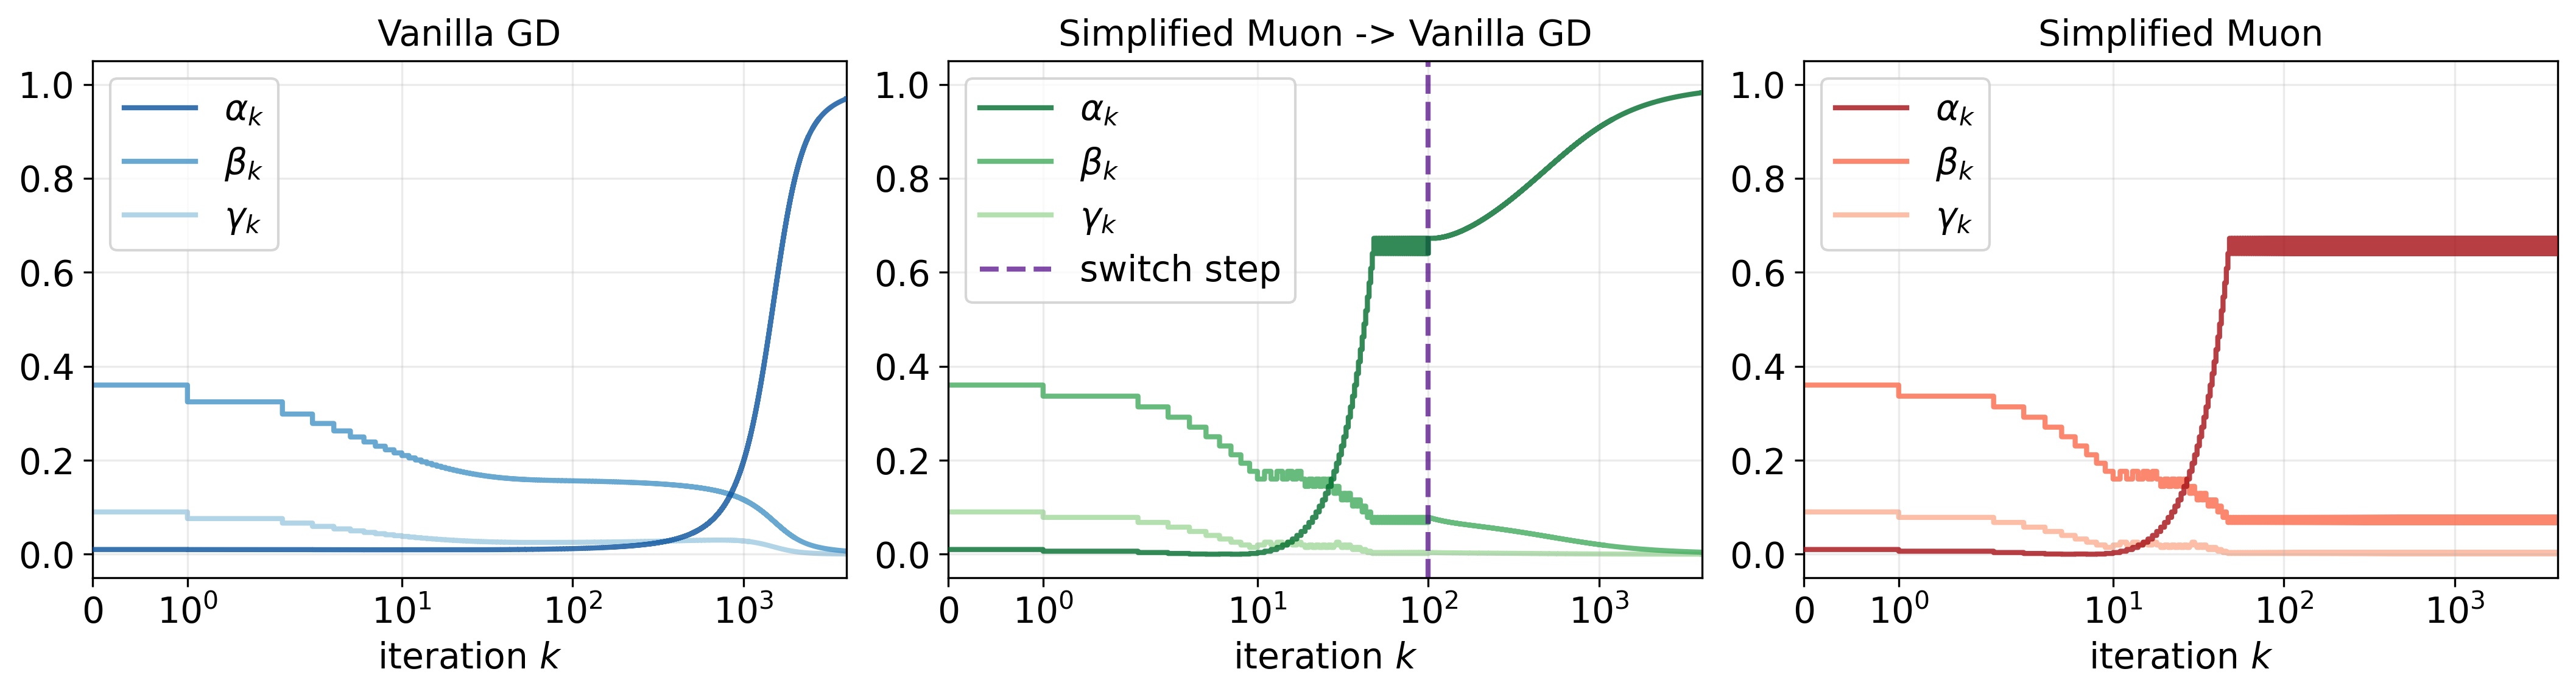

Saved figure to: mixed_spiked_ms_psd_coefficients.pdf


In [10]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14.2, 3.9), gridspec_kw=dict(width_ratios=[1.0, 1.0, 1.0]))

ax0.plot(traj1.iterations, traj1.alpha, color=blues[0], lw=2.0, 
         label=r"$\alpha_k$", drawstyle="steps-post", zorder=3, alpha=0.8)
ax0.plot(traj1.iterations, traj1.beta, color=blues[1], lw=2.0, 
         label=r"$\beta_k$",  drawstyle="steps-post", zorder=2, alpha=0.8)
ax0.plot(traj1.iterations, traj1.gamma, color=blues[2], lw=2.0, 
         label=r"$\gamma_k$", drawstyle="steps-post", zorder=1, alpha=0.8)
ax0.set_xlabel(r"iteration $k$", fontsize=14)
ax0.grid(True, alpha=0.25)
ax0.set_ylim(-0.05, 1.05)
ax0.set_xlim(float(np.min(traj1.iterations)), float(np.max(traj1.iterations)))
ax0.set_xscale("symlog")
ax0.legend(loc="upper left", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(rf"Vanilla GD", fontsize=14)

ax1.plot(traj2.iterations, traj2.alpha, color=greens[0], lw=2.0, 
         label=r"$\alpha_k$", drawstyle="steps-post", zorder=3, alpha=0.8)
ax1.plot(traj2.iterations, traj2.beta, color=greens[1], lw=2.0, 
         label=r"$\beta_k$",  drawstyle="steps-post", zorder=2, alpha=0.8)
ax1.plot(traj2.iterations, traj2.gamma, color=greens[2], lw=2.0, 
         label=r"$\gamma_k$", drawstyle="steps-post", zorder=1, alpha=0.8)
ax1.axvline(args.switch_step, label="switch step",
            color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel(r"iteration $k$", fontsize=14)
ax1.grid(True, alpha=0.25)
ax1.set_ylim(-0.05, 1.05)
ax1.set_xlim(float(np.min(traj2.iterations)), float(np.max(traj2.iterations)))
ax1.set_xscale("symlog")
ax1.legend(loc="upper left", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(rf"Simplified Muon -> Vanilla GD", fontsize=14)

ax2.plot(traj3.iterations, traj3.alpha, color=reds[0], lw=2.0, 
         label=r"$\alpha_k$", drawstyle="steps-post", zorder=3, alpha=0.8)
ax2.plot(traj3.iterations, traj3.beta, color=reds[1], lw=2.0, 
         label=r"$\beta_k$",  drawstyle="steps-post", zorder=2, alpha=0.8)
ax2.plot(traj3.iterations, traj3.gamma, color=reds[2], lw=2.0, 
         label=r"$\gamma_k$", drawstyle="steps-post", zorder=1, alpha=0.8)
ax2.set_xlabel(r"iteration $k$", fontsize=14)
ax2.grid(True, alpha=0.25)
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(float(np.min(traj3.iterations)), float(np.max(traj3.iterations)))
ax2.set_xscale("symlog")
ax2.legend(loc="upper left", frameon=True, fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title(rf"Simplified Muon", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("mixed_spiked_ms_psd_coefficients.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: mixed_spiked_ms_psd_coefficients.pdf")

### Plot Results (reduced loss)

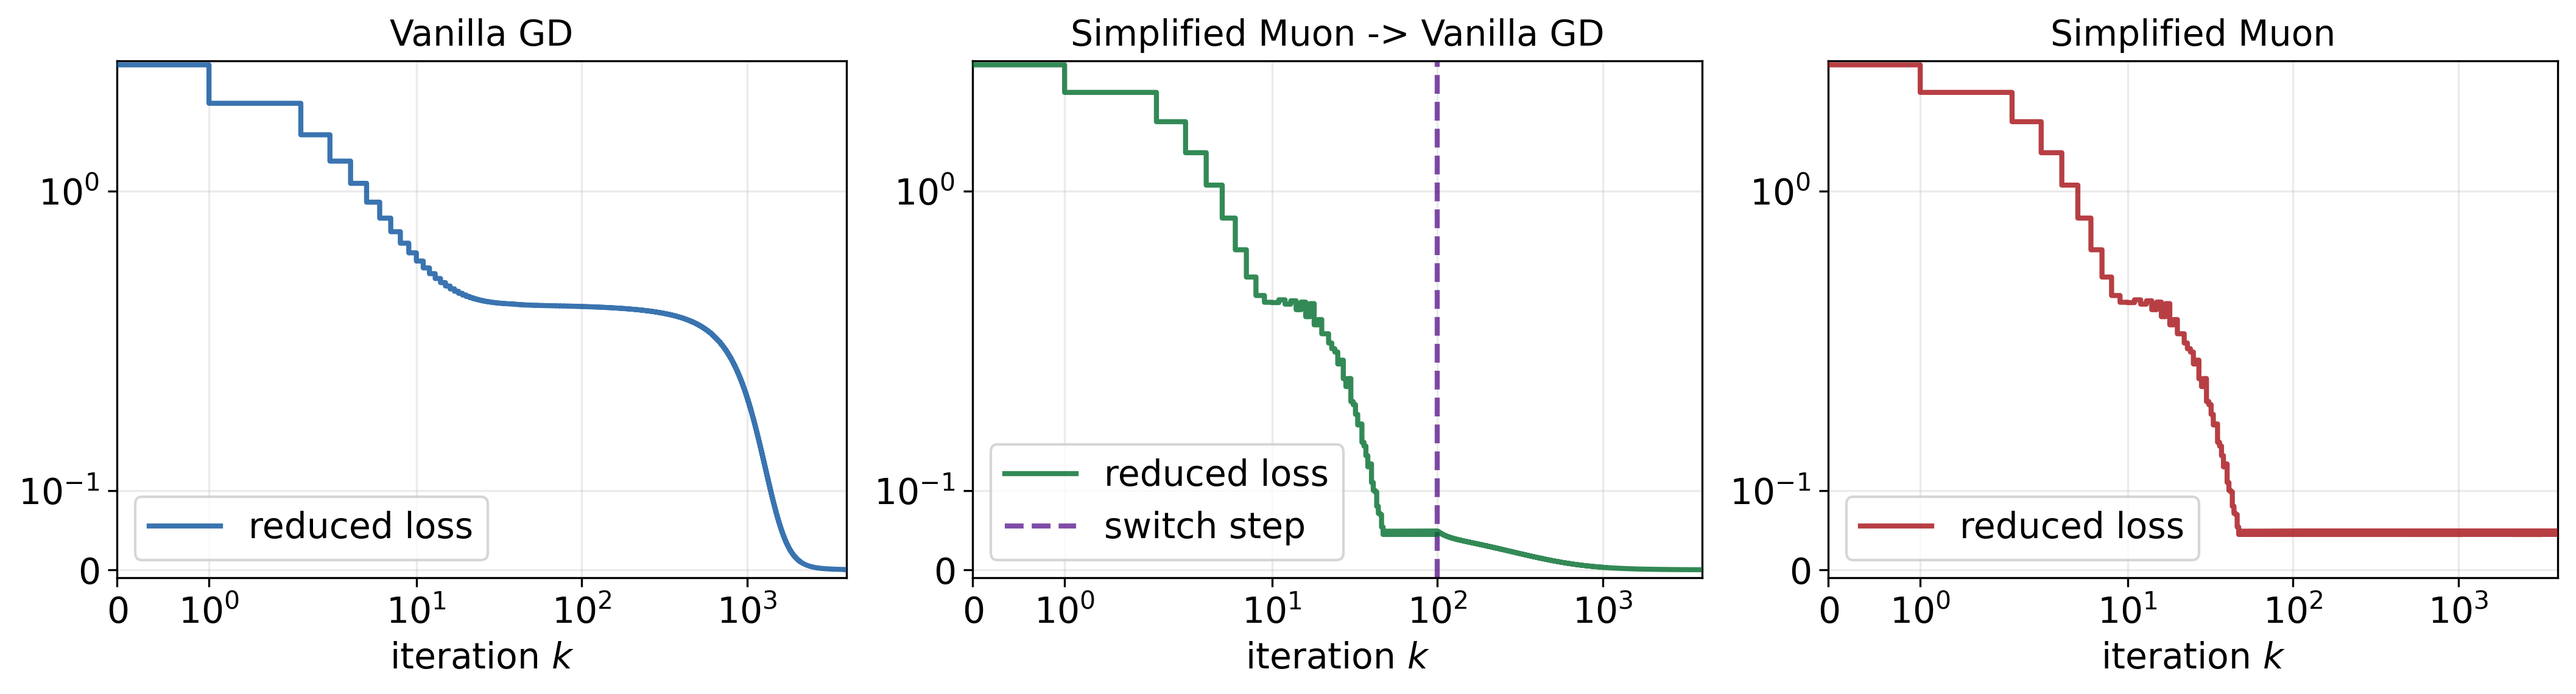

Saved figure to: mixed_spiked_ms_psd_loss.pdf


In [11]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14.2, 3.9), gridspec_kw=dict(width_ratios=[1.0, 1.0, 1.0]))

ax0.plot(traj1.iterations, traj1.loss, color=blues[0], lw=2.0, 
         label=r"reduced loss", drawstyle="steps-post", zorder=3, alpha=0.8)
ax0.set_xlabel(r"iteration $k$", fontsize=14)
ax0.grid(True, alpha=0.25)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([traj1.loss.max(), traj2.loss.max(), traj3.loss.max()])) * 1e-1)
ax0.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax0.set_ylim(bottom=-0.01, top=3.5)
ax0.set_xlim(float(np.min(traj1.iterations)), float(np.max(traj1.iterations)))
ax0.set_xscale("symlog")
ax0.legend(loc="lower left", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(rf"Vanilla GD", fontsize=14)

ax1.plot(traj2.iterations, traj2.loss, color=greens[0], lw=2.0, 
         label=r"reduced loss", drawstyle="steps-post", zorder=3, alpha=0.8)
ax1.axvline(args.switch_step, label="switch step",
            color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel(r"iteration $k$", fontsize=14)
ax1.grid(True, alpha=0.25)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([traj1.loss.max(), traj2.loss.max(), traj3.loss.max()])) * 1e-1)
ax1.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax1.set_ylim(bottom=-0.01, top=3.5)
ax1.set_xlim(float(np.min(traj2.iterations)), float(np.max(traj2.iterations)))
ax1.set_xscale("symlog")
ax1.legend(loc="lower left", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(rf"Simplified Muon -> Vanilla GD", fontsize=14)

ax2.plot(traj3.iterations, traj3.loss, color=reds[0], lw=2.0, 
         label=r"reduced loss", drawstyle="steps-post", zorder=3, alpha=0.8)
ax2.set_xlabel(r"iteration $k$", fontsize=14)
ax2.grid(True, alpha=0.25)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([traj1.loss.max(), traj2.loss.max(), traj3.loss.max()])) * 1e-1)
ax2.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax2.set_ylim(bottom=-0.01, top=3.5)
ax2.set_xlim(float(np.min(traj3.iterations)), float(np.max(traj3.iterations)))
ax2.set_xscale("symlog")
ax2.legend(loc="lower left", frameon=True, fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title(rf"Simplified Muon", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("mixed_spiked_ms_psd_loss.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: mixed_spiked_ms_psd_loss.pdf")

### Plot Results (distance to ground truth $P_\star$)

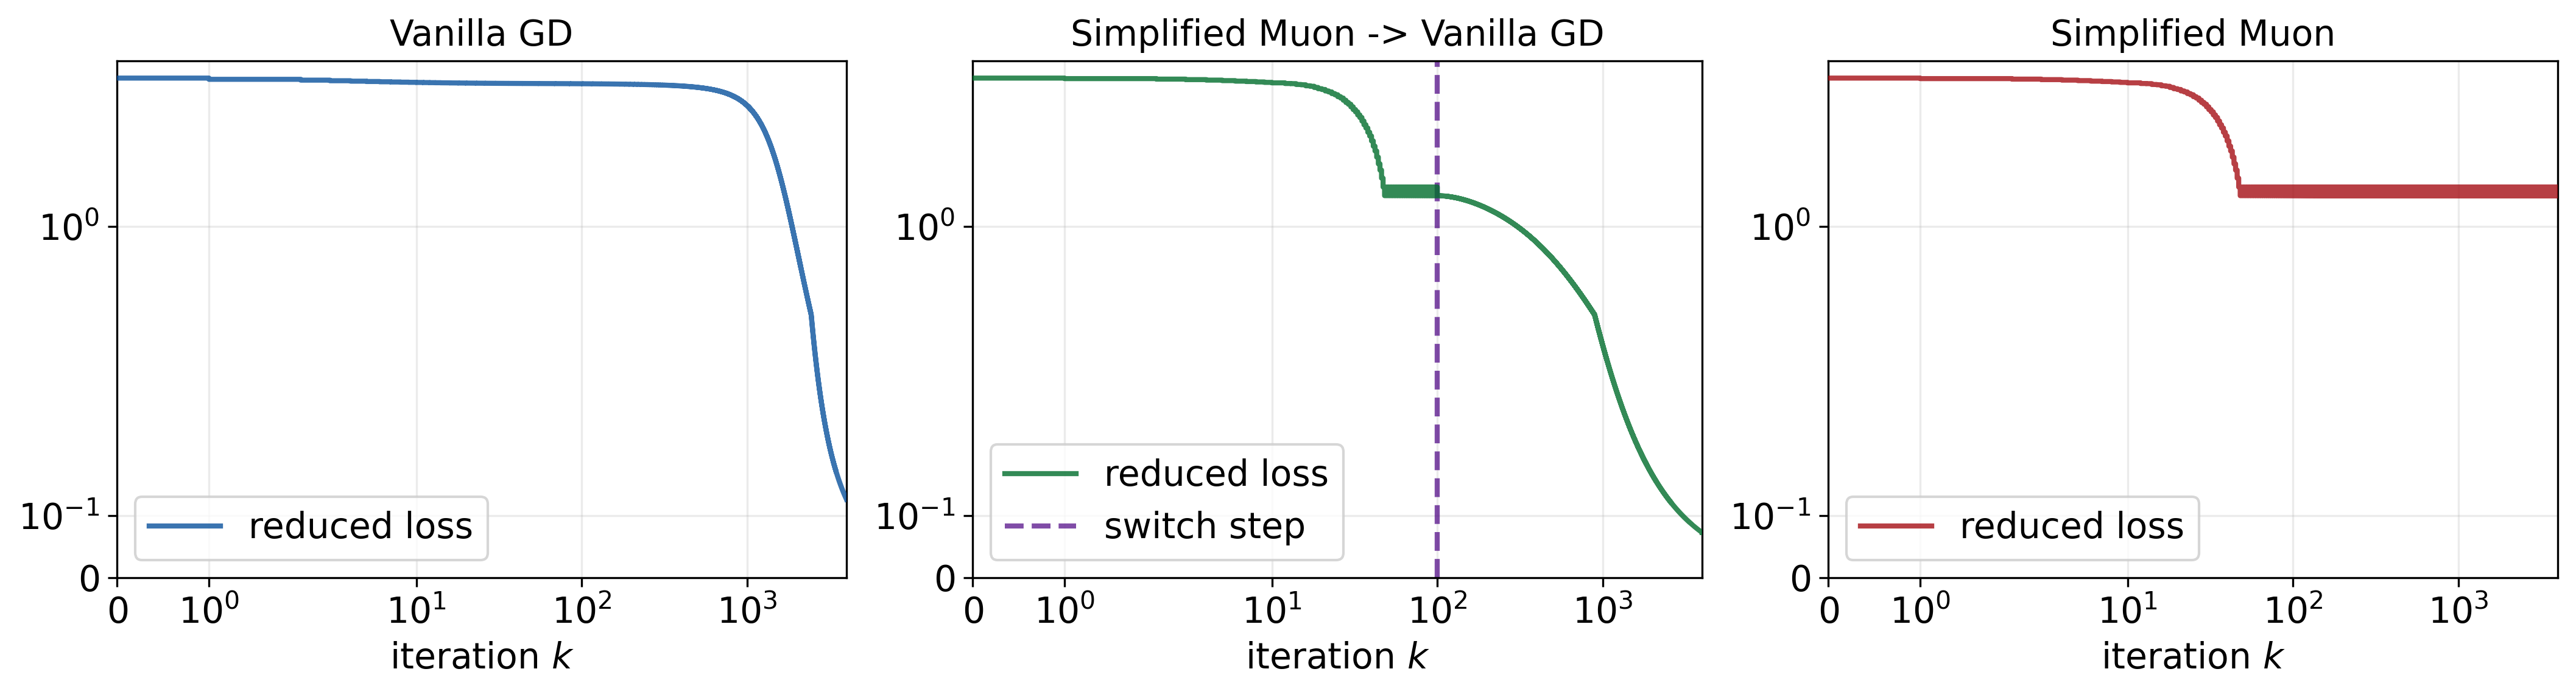

Saved figure to: mixed_spiked_ms_psd_distance.pdf


In [12]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14.2, 3.9), gridspec_kw=dict(width_ratios=[1.0, 1.0, 1.0]))

ax0.plot(traj1.iterations, traj1.distance, color=blues[0], lw=2.0, 
         label=r"reduced loss", drawstyle="steps-post", zorder=3, alpha=0.8)
ax0.set_xlabel(r"iteration $k$", fontsize=14)
ax0.grid(True, alpha=0.25)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([traj1.distance.max(), traj2.distance.max(), traj3.distance.max()])) * 1e-1)
ax0.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax0.set_ylim(bottom=0, top=5)
ax0.set_xlim(float(np.min(traj1.iterations)), float(np.max(traj1.iterations)))
ax0.set_xscale("symlog")
ax0.legend(loc="lower left", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(rf"Vanilla GD", fontsize=14)

ax1.plot(traj2.iterations, traj2.distance, color=greens[0], lw=2.0, 
         label=r"reduced loss", drawstyle="steps-post", zorder=3, alpha=0.8)
ax1.axvline(args.switch_step, label="switch step",
            color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel(r"iteration $k$", fontsize=14)
ax1.grid(True, alpha=0.25)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([traj1.distance.max(), traj2.distance.max(), traj3.distance.max()])) * 1e-1)
ax1.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax1.set_ylim(bottom=0, top=5)
ax1.set_xlim(float(np.min(traj2.iterations)), float(np.max(traj2.iterations)))
ax1.set_xscale("symlog")
ax1.legend(loc="lower left", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(rf"Simplified Muon -> Vanilla GD", fontsize=14)

ax2.plot(traj3.iterations, traj3.distance, color=reds[0], lw=2.0, 
         label=r"reduced loss", drawstyle="steps-post", zorder=3, alpha=0.8)
ax2.set_xlabel(r"iteration $k$", fontsize=14)
ax2.grid(True, alpha=0.25)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([traj1.distance.max(), traj2.distance.max(), traj3.distance.max()])) * 1e-1)
ax2.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax2.set_ylim(bottom=0, top=5)
ax2.set_xlim(float(np.min(traj3.iterations)), float(np.max(traj3.iterations)))
ax2.set_xscale("symlog")
ax2.legend(loc="lower left", frameon=True, fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title(rf"Simplified Muon", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("mixed_spiked_ms_psd_distance.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: mixed_spiked_ms_psd_distance.pdf")

### Plot Results (3D trajectories)

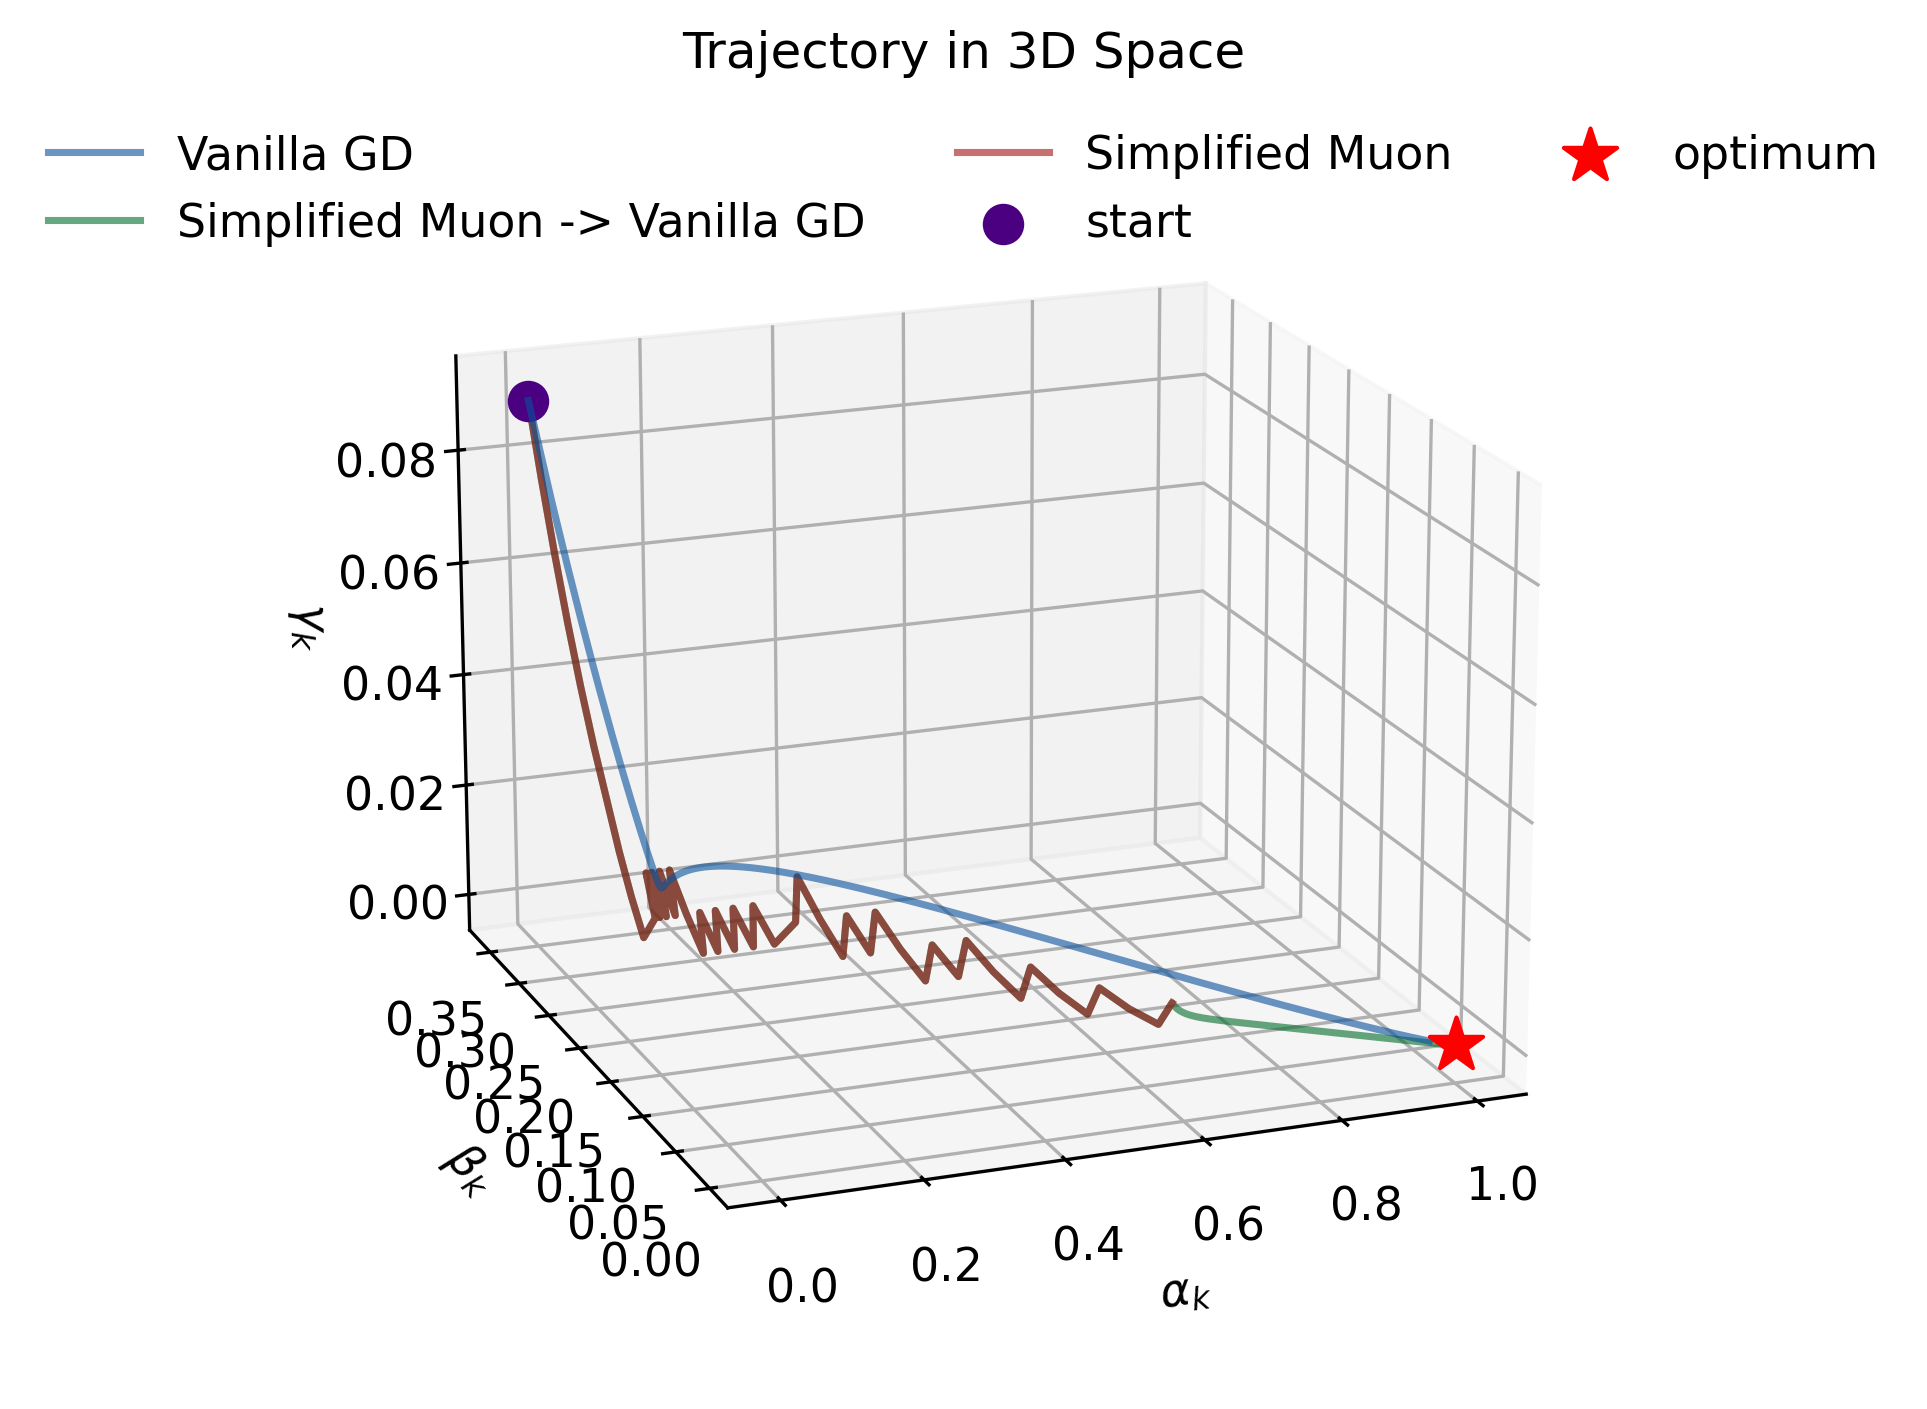

Saved figure to: mixed_spiked_ms_psd_trajectory.pdf


In [13]:
# Plot 3d Trajectory
fig3d = plt.figure()
ax3d = fig3d.add_subplot(1, 1, 1, projection='3d')
ax3d.plot(traj1.alpha, traj1.beta, traj1.gamma, color=blues[0], 
          label='Vanilla GD', lw=1.7, alpha=0.6, zorder=3)
ax3d.plot(traj2.alpha, traj2.beta, traj2.gamma, color=greens[0], 
          label='Simplified Muon -> Vanilla GD', lw=1.7, alpha=0.6, zorder=1)
ax3d.plot(traj3.alpha, traj3.beta, traj3.gamma, color=reds[0], 
          label='Simplified Muon', lw=1.7, alpha=0.6, zorder=2)

# markers
ax3d.scatter(args.a0 ** 2, args.b0 ** 2, args.c0 ** 2, color='#4B0082', marker='o', s=80, label='start')
ax3d.scatter(1, 0, 0, color='red', marker='*', s=180, label='optimum')

ax3d.set_xlabel(r'$\alpha_k$', fontsize=11)
ax3d.set_ylabel(r'$\beta_k$', fontsize=11)
ax3d.set_zlabel(r'$\gamma_k$', fontsize=11)
ax3d.tick_params(axis='x', labelsize=11)
ax3d.tick_params(axis='y', labelsize=11)
ax3d.tick_params(axis='z', labelsize=11)
ax3d.set_title('Trajectory in 3D Space', fontsize=12)
ax3d.legend(frameon=False, ncol=3, loc='upper center', fontsize=11)
ax3d.view_init(elev=18, azim=-111)

plt.tight_layout()
plt.show()
fig3d.savefig("mixed_spiked_ms_psd_trajectory.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: mixed_spiked_ms_psd_trajectory.pdf")